In [1]:
import pandas as pd

macro = pd.read_csv('../../fred_md.csv')
macro = macro.iloc[1:, :]  # Remove first row with units
macro.head() 

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
1,1/1/1959,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9616,23.3868,22.2620,31.6664,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,278713.9773,17819.01912,22.3917,23.7024,22.4549,31.8987,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7142,23.8459,22.5651,31.8987,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,283362.7075,17978.97983,23.1981,24.1903,22.8957,32.4019,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN
5,5/1/1959,2642.720,2486.4,15.622,285307.2201,18119.82573,23.5476,24.3911,23.1161,32.5567,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.0,12646.0,80.7315,NaN


In [2]:
fed_data = pd.read_csv('fomc_training_data.csv')
fed_data.tail()

,date,decision,fed_funds_rate,full_text,text_length,economic_outlook,policy_discussion,risks_concerns,future_guidance
120,"March 18-19, 2025",hold,4.25,FOMC FEDERAL RESERVE SYSTEM Minutes of the Fed...,49436,. They also reflected on how both the Committe...,"Strategy, Tools, and Communications Committee ...",rather than a base case of a significant deter...,NaN
121,"June 17-18, 2025",hold,4.25,FOMC FEDERAL RESERVE SYSTEM Minutes of the Fed...,48086,ed qualitative and quantitative tools that are...,"Strategy, Tools, and Communications Committee ...",and uncertainty that are relevant for monetary...,NaN
122,"July 29-30, 2025",hold,4.25,FOMC FEDERAL RESERVE SYSTEM Minutes of the Fed...,48173,. Participants noted that the Committee was cl...,"Strategy, Tools, and Communications Participan...",associated with trade policy developments cont...,NaN
123,"September 16-17, 2025",cut,4.00,FOMC FEDERAL RESERVE SYSTEM Minutes of the Fed...,42901,incorporated in most private -sector forecasts...,", including their projections of the federal f...",to the labor market had increased . Median mod...,changes . In discussing risk -management consi...
124,"October 28-29, 2025",cut,3.75,FOMC FEDERAL RESERVE SYSTEM Minutes of the Fed...,56672,"s little changed, and they appeared to continu...","as well as smooth market functioning , and tha...",to both the control of the policy rate and the...,NaN


In [3]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Load FOMC statements
statements = pd.read_csv('fomc_training_data.csv')  # columns: date, text

# 2. Vectorize
vectorizer = CountVectorizer(
    max_features=500,
    stop_words='english',
    min_df=2
)
doc_term = vectorizer.fit_transform(statements['full_text'])

# 3. Fit LDA (5 topics)
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)
topics = lda.fit_transform(doc_term)

# 4. Topics are now features
topics_df = pd.DataFrame(topics, columns=['topic1', 'topic2', 'topic3', 'topic4', 'topic5'])
topics_df['date'] = statements['date']

# 5. Merge with your data
# topics_df.to_csv('fomc_topics.csv')
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]  # Top 10 words
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: participants, board, inflation, federal, market, rate, policy, division, monetary, economic
Topic 2: projections, rate, participants, federal, percent, inflation, economic, longer, run, funds
Topic 3: market, inflation, rate, federal, economic, policy, participants, committee, labor, term
Topic 4: participants, economic, inflation, committee, federal, market, policy, rate, term, period
Topic 5: committee, market, foreign, federal, bank, open, inflation, january, reserve, rate


In [4]:
import pandas as pd
import numpy as np
from datetime import datetime


# 2. Parse Fed meeting dates to month
def parse_fomc_date(date_str):
    """Convert 'January 26-27, 2010' to '2010-01-01'"""
    # Extract month and year
    parts = date_str.split(',')
    year = parts[-1].strip()
    month_str = parts[0].split()[0]  # Get first word (month name)
    
    # Convert month name to number
    month_num = datetime.strptime(month_str, '%B').month
    
    # Return first day of month
    return f"{year}-{month_num:02d}-01"

fed_data['date'] = fed_data['date'].apply(parse_fomc_date)
fed_data['date'] = pd.to_datetime(fed_data['date'])

# 3. Parse macro dates
macro['sasdate'] = pd.to_datetime(macro['sasdate'])

# 4. Merge Fed data with macro data
# Get macro data from the month of the meeting
fed_with_macro = fed_data.merge(
    macro, 
    left_on='date', 
    right_on='sasdate',
    how='left'
)

print(f"Fed meetings: {len(fed_data)}")
print(f"Matched with macro: {len(fed_with_macro)}")
print(f"Missing matches: {fed_with_macro['sasdate'].isna().sum()}")


# 11. Save for NN training
# np.save('X_fed_prediction.npy', X)
# np.save('y_fed_prediction.npy', y)
# fed_training.to_csv('fed_training_ready.csv', index=False)

Fed meetings: 125
Matched with macro: 125
Missing matches: 2


In [5]:
fed_with_macro.head(1)

,date,decision,fed_funds_rate,full_text,text_length,economic_outlook,policy_discussion,risks_concerns,future_guidance,sasdate,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,2010-01-01,hold,0.25,Minutes of the Federal Open Market Committee J...,100094,. The Committee made no decisions about asset ...,over the longer term. Participants generally a...,made investors more reluctant to hold debt iss...,NaN,2010-01-01,...,94.68,85.398,20.09,23.03,18.43,74.4,222450.86,710973.4,2325.1131,20.9652


In [6]:
# Macro variables to calculate changes for
macro_vars = ['UNRATE', 'CPIAUCSL', 'INDPRO', 'PAYEMS', 'FEDFUNDS']

for var in macro_vars:
    # forward fill
    fed_with_macro[var] = fed_with_macro[var].ffill()
    # Convert to numeric
    fed_with_macro[var] = pd.to_numeric(fed_with_macro[var], errors='coerce')
    
    # Calculate change from previous meeting
    fed_with_macro[f'{var}_change'] = fed_with_macro[var].diff()
    
    # Calculate percent change
    fed_with_macro[f'{var}_pct_change'] = fed_with_macro[var].pct_change()


# 6. Add LDA topics
topics_df['date'] = topics_df['date'].apply(parse_fomc_date)
topics_df['date'] = pd.to_datetime(topics_df['date'])
fed_with_macro = fed_with_macro.merge(
    topics_df,
    left_on='date',
    right_on='date',
    how='left'
)

# 7. Create target variable (decision)
decision_map = {'hold': 0, 'hike': 1, 'cut': 2}
fed_with_macro['decision_label'] = fed_with_macro['decision'].map(decision_map)



In [97]:
# 8. Select features for NN
feature_cols = [
    # Macro changes
    'UNRATE_change', 'UNRATE_pct_change',
    'CPIAUCSL_change', 'CPIAUCSL_pct_change',
    'INDPRO_change', 'INDPRO_pct_change',
    'PAYEMS_change', 'PAYEMS_pct_change',
    # Current levels
    'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'INDPRO', 'PAYEMS',
    # LDA topics
    'topic1', 'topic2', 'topic3', 'topic4', 'topic5',
    # Projections
    
    # Rate itself
    'fed_funds_rate'
]

# 9. Clean data - remove first row (no previous meeting for changes)
fed_training = fed_with_macro.iloc[1:].copy()

# Remove rows with NaNs
fed_training = fed_training.dropna(subset=feature_cols + ['decision_label'])
fed_training = fed_training[feature_cols + ['decision_label']]



# 10. Extract X and y
X = np.array(fed_training.drop(['fed_funds_rate'], axis=1))
y = np.array(fed_training['fed_funds_rate'])

print(f"\nFinal training data shape: {X.shape}")
print(f"Class distribution:")
print(fed_training['decision_label'].value_counts())



Final training data shape: (124, 19)
Class distribution:
decision_label
0    95
1    20
2     9
Name: count, dtype: int64


In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler = StandardScaler()
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = scaler.transform(X)

y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

X_train = X[38:100]
y_train = y[38:100]

X_val = X[100:112]
y_val = y[100:112]

X_test = X[112:]
y_test = y[112:]


In [99]:
y_test.min(), y_test.max()

(np.float64(0.6666666666666665), np.float64(0.9523809523809523))

In [100]:
class SimpleNN:
    def __init__(self, X, hidden_dim=64, lr=0.001):
        self.input_dim = X.shape[1]
        np.random.seed(42)
        self.W1 = np.random.randn(self.input_dim, hidden_dim) / np.sqrt(self.input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, 1) / np.sqrt(hidden_dim)
        self.b2 = 0.0 
        self.lr = lr
        self.errors = []

    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def train(self, X, y, epochs=200):
        y = y.reshape(-1, 1)

        for e in range(epochs):
            z1 = X @ self.W1 + self.b1
            a1 = self.relu(z1)
            z2 = a1 @ self.W2 + self.b2
            pred = z2.reshape(-1, 1)
            
            # loss
            loss = np.mean((pred - y)**2)
            # back propagation
            dloss = 2 * (pred - y) / len(y)
            dW2 = a1.T @ dloss
            db2 = np.sum(dloss, axis=0)

            da1 = dloss @ self.W2.T
            dz1 = da1 * self.relu_deriv(z1)

            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0)

            # gradient descent
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

            if e % 10 == 0:
                self.errors.append(loss)
                print(f"Epoch {e}, Loss: {loss:.4f}")

    def predict(self, X):
        return self.relu(X @ self.W1 + self.b1) @ self.W2 + self.b2

In [101]:
nn = SimpleNN(X=X_train, hidden_dim=16, lr=0.001)

nn.train(X_train, y_train, epochs=300)

nn_pred = nn.predict(X_test)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_rmse

Epoch 0, Loss: 3.6908
Epoch 10, Loss: 0.0438
Epoch 20, Loss: 0.0416
Epoch 30, Loss: 0.0398
Epoch 40, Loss: 0.0384
Epoch 50, Loss: 0.0374
Epoch 60, Loss: 0.0366
Epoch 70, Loss: 0.0360
Epoch 80, Loss: 0.0356
Epoch 90, Loss: 0.0353
Epoch 100, Loss: 0.0350
Epoch 110, Loss: 0.0349
Epoch 120, Loss: 0.0347
Epoch 130, Loss: 0.0346
Epoch 140, Loss: 0.0345
Epoch 150, Loss: 0.0344
Epoch 160, Loss: 0.0343
Epoch 170, Loss: 0.0342
Epoch 180, Loss: 0.0342
Epoch 190, Loss: 0.0341
Epoch 200, Loss: 0.0340
Epoch 210, Loss: 0.0339
Epoch 220, Loss: 0.0338
Epoch 230, Loss: 0.0336
Epoch 240, Loss: 0.0333
Epoch 250, Loss: 0.0331
Epoch 260, Loss: 0.0328
Epoch 270, Loss: 0.0325
Epoch 280, Loss: 0.0323
Epoch 290, Loss: 0.0318


np.float64(0.6259617999441274)

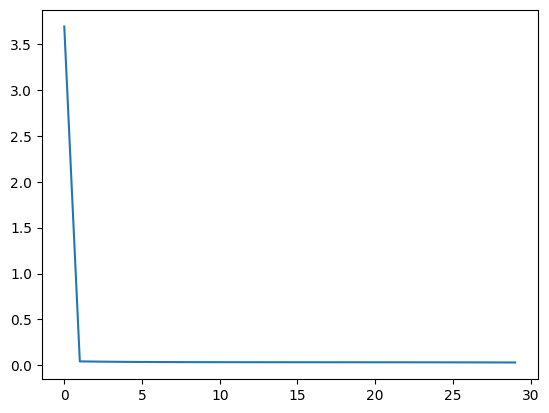

In [102]:
plt.plot(nn.errors)

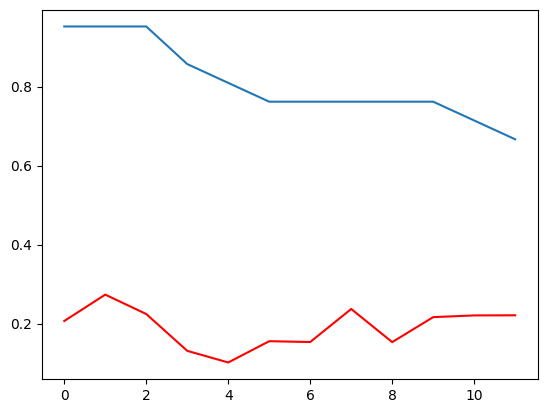

In [103]:
y_scale = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()
y_test_scaled = y_scale[112:]

plt.plot(y_test_scaled)
plt.plot(nn_pred, color='red')

Epoch 0, Loss: 0.0442
Epoch 10, Loss: 0.0352
Epoch 20, Loss: 0.0299
Epoch 30, Loss: 0.0266
Epoch 40, Loss: 0.0246
Epoch 50, Loss: 0.0233
Epoch 60, Loss: 0.0223
Epoch 70, Loss: 0.0216
Epoch 80, Loss: 0.0211
Epoch 90, Loss: 0.0206
Epoch 100, Loss: 0.0202
Epoch 110, Loss: 0.0198
Epoch 120, Loss: 0.0194
Epoch 130, Loss: 0.0191
Epoch 140, Loss: 0.0187
Epoch 150, Loss: 0.0184
Epoch 160, Loss: 0.0181
Epoch 170, Loss: 0.0178
Epoch 180, Loss: 0.0176
Epoch 190, Loss: 0.0173
Epoch 200, Loss: 0.0170
Epoch 210, Loss: 0.0168
Epoch 220, Loss: 0.0165
Epoch 230, Loss: 0.0163
Epoch 240, Loss: 0.0160
Epoch 250, Loss: 0.0158
Epoch 260, Loss: 0.0156
Epoch 270, Loss: 0.0154
Epoch 280, Loss: 0.0152
Epoch 290, Loss: 0.0149
Epoch 300, Loss: 0.0147
Epoch 310, Loss: 0.0145
Epoch 320, Loss: 0.0143
Epoch 330, Loss: 0.0141
Epoch 340, Loss: 0.0140
Epoch 350, Loss: 0.0138
Epoch 360, Loss: 0.0136
Epoch 370, Loss: 0.0135
Epoch 380, Loss: 0.0133
Epoch 390, Loss: 0.0132
Epoch 400, Loss: 0.0130
Epoch 410, Loss: 0.0129
Epo

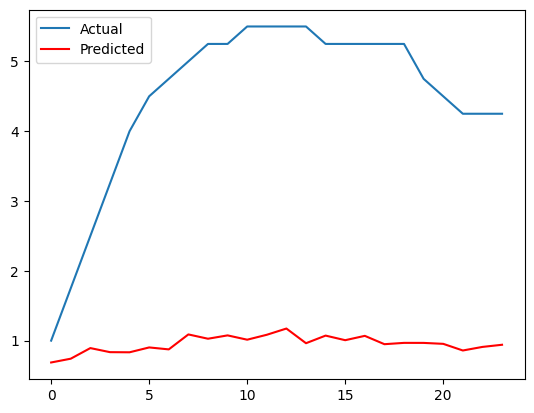

In [114]:
# 1. Create NEXT rate target
fed_training['fed_funds_rate_next'] = fed_training['fed_funds_rate'].shift(-1)
fed_training = fed_training[:-1].dropna()

# 2. Better features (no data leakage)
feature_cols = [
    'UNRATE_change', 'CPIAUCSL_change', 'INDPRO_change', 'PAYEMS_change',
    'UNRATE', 'CPIAUCSL',
    'topic1', 'topic2', 'topic3', 'topic4', 'topic5',
    'fed_funds_rate',  # CURRENT rate (to predict NEXT)
]

# 3. Extract X and y
X = fed_training[feature_cols].values
y = fed_training['fed_funds_rate_next'].values

# 4. Scale
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# 5. Split (random or use last 20% for test)
split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# 6. Train
nn = SimpleNN(X=X_train, hidden_dim=8, lr=0.01)
nn.train(X_train, y_train, epochs=2000)

# 7. Evaluate
nn_pred = nn.predict(X_test)
nn_pred_original = scaler_y.inverse_transform(nn_pred.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_original, nn_pred_original))
print(f"RMSE: {rmse:.4f}")

# Plot
plt.plot(y_test_original, label='Actual')
plt.plot(nn_pred_original, label='Predicted', color='red')
plt.legend()
plt.show()

In [118]:
nn.predict(X_scaled[-1,:])

array([0.13162362])

array([-1.00000000e-01,  1.48300000e+00, -1.64200000e-01,  1.11000000e+02,
        4.00000000e+00,  3.19086000e+02,  8.76255237e-01,  3.34406921e-03,
        1.62772863e-02,  4.47893215e-03,  9.96444751e-02,  4.25000000e+00])

In [120]:
y_scaled[-1]

np.float64(0.7619047619047619)